# Strategy Comparison: Network Markowitz vs Baselines + Graph Diversification
## Replicating Giudici et al. (2020) Experiment + Maximum Independent Set Diversification

**Paper:** Network Models to Improve Automated Cryptocurrency Portfolio Management

**Strategies Compared:**
1. **CRIX** - Cryptocurrency Index (Benchmark)
2. **Equally Weighted (EW)** - Naive Portfolio (1/N)
3. **Classical Markowitz (CM)** - Traditional Mean-Variance
4. **Glasso Markowitz (GM)** - Markowitz + Graphical Lasso
5. **Network Markowitz (NW)** - RMT + MST (γ=0)
6. **Network Markowitz + Centrality** - Various γ values
7. **Graph Diversification (GD)** - Maximum Independent Set (NEW)

**Performance Metrics:**
- Cumulative Returns
- Sharpe Ratio
- Value at Risk (VaR 95%)
- Rachev Ratio
- Maximum Drawdown
- Volatility

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx  # NEW: For graph-based diversification
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1. Load Data

In [12]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices = pd.read_excel(excel_file, sheet_name='Prices', index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00


## 2. Helper Functions

In [13]:
def apply_rmt_filter(returns_data):
    """Apply Random Matrix Theory filtering"""
    T, N = returns_data.shape
    Q = T / N
    
    C = np.corrcoef(returns_data.T)
    eigenvalues, eigenvectors = eigh(C)
    eigenvalues = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]
    
    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    significant_mask = eigenvalues > lambda_plus
    
    Lambda_filtered = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered = eigenvectors @ Lambda_filtered @ eigenvectors.T
    
    return C_filtered

def build_mst(correlation_matrix):
    """Build Minimal Spanning Tree"""
    distance_matrix = np.sqrt(2 - 2*correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix

def compute_eigenvector_centrality(distance_matrix):
    """Compute eigenvector centrality"""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    centrality = principal_eigenvector / principal_eigenvector.sum()
    
    return centrality

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """
    NEW: Graph-based diversification using Maximum Independent Set
    
    Selects assets that are minimally correlated with each other by:
    1. Creating a graph where edges represent high correlation
    2. Finding the maximum independent set (no two connected nodes)
    3. Prioritizing assets with higher mean returns
    
    Parameters:
    -----------
    returns_window : pd.DataFrame
        Historical returns data
    corr_threshold : float
        Correlation threshold for creating edges (default: 0.4)
    
    Returns:
    --------
    list : Selected asset names
    """
    corr_mat = returns_window.corr()
    G = nx.Graph()
    
    # Sort assets by mean return (descending)
    assets = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    
    # Add edges for highly correlated assets
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    
    # Find maximum independent set (assets with minimal correlation)
    return list(nx.approximation.maximum_independent_set(G))

def calculate_var(returns, confidence=0.95):
    """Calculate Value at Risk"""
    return np.percentile(returns, (1-confidence)*100)

def calculate_rachev_ratio(returns, alpha=0.10):
    """Calculate Rachev Ratio (CVaR ratio)"""
    threshold_upper = np.percentile(returns, (1-alpha)*100)
    threshold_lower = np.percentile(returns, alpha*100)
    
    cvar_upper = returns[returns >= threshold_upper].mean()
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0

def calculate_max_drawdown(cumulative_returns):
    """Calculate Maximum Drawdown"""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown.min()

print("✅ Helper functions defined")

✅ Helper functions defined


## 3. Strategy Implementations

In [14]:
class PortfolioStrategy:
    """Base class for portfolio strategies"""
    
    def __init__(self, name):
        self.name = name
        self.weights_history = []
        self.returns_history = []
    
    def get_weights(self, returns_data):
        """Override this method in subclasses"""
        raise NotImplementedError
    
    def calculate_portfolio_return(self, weights, future_returns):
        """Calculate portfolio return for given weights"""
        return np.dot(weights, future_returns)

class EquallyWeighted(PortfolioStrategy):
    """Equally Weighted (1/N) Portfolio"""
    
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n

class ClassicalMarkowitz(PortfolioStrategy):
    """Classical Markowitz Mean-Variance Optimization"""
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        cov_matrix = returns_data.cov().values
        
        def objective(w):
            return w @ cov_matrix @ w
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz with Graphical Lasso Filtering"""
    
    def __init__(self, name="Glasso Markowitz", alpha=0.01):
        super().__init__(name)
        self.alpha = alpha
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        
        # Apply Graphical Lasso
        try:
            glasso = GraphicalLassoCV(alphas=[self.alpha], cv=3)
            glasso.fit(returns_data.values)
            cov_matrix = glasso.covariance_
        except:
            cov_matrix = returns_data.cov().values
        
        def objective(w):
            return w @ cov_matrix @ w
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz with RMT + MST + Centrality"""
    
    def __init__(self, name="Network Markowitz", gamma=0):
        super().__init__(name)
        self.gamma = gamma
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        mean_returns = returns_data.mean().values
        std_devs = returns_data.std().values
        
        # Apply RMT + MST
        C_filtered = apply_rmt_filter(returns_data)
        dist_matrix = build_mst(C_filtered)
        centrality = compute_eigenvector_centrality(dist_matrix)
        
        # Filtered covariance
        cov_filtered = np.outer(std_devs, std_devs) * C_filtered
        
        def objective(w):
            portfolio_variance = w @ cov_filtered @ w
            centrality_penalty = self.gamma * np.sum(centrality * w)
            return portfolio_variance + centrality_penalty
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mean_returns - mean_returns.mean()}
        ]
        
        bounds = tuple((0, 1) for _ in range(n_assets))
        w0 = np.ones(n_assets) / n_assets
        
        result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        return result.x if result.success else w0

class GraphDiversification(PortfolioStrategy):
    """NEW: Graph-based Diversification using Maximum Independent Set"""
    
    def __init__(self, name="Graph Diversification", corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold
    
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        all_assets = returns_data.columns.tolist()
        
        # Get diversified asset selection
        selected_assets = get_assets_graph_diversify(returns_data, self.corr_threshold)
        
        # Equal weight among selected assets
        weights = np.zeros(n_assets)
        n_selected = len(selected_assets)
        
        if n_selected > 0:
            for asset in selected_assets:
                idx = all_assets.index(asset)
                weights[idx] = 1.0 / n_selected
        else:
            # Fallback to equal weight if no assets selected
            weights = np.ones(n_assets) / n_assets
        
        return weights

print("✅ Strategy classes defined")

✅ Strategy classes defined


## 4. Backtesting Framework

In [15]:
def backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7, transaction_cost=0.001):
    """
    Backtest a portfolio strategy
    
    Parameters:
    -----------
    strategy : PortfolioStrategy
        Strategy to backtest
    df_returns : pd.DataFrame
        Returns data
    window_size : int
        Training window size (days)
    rebalance_freq : int
        Rebalancing frequency (days)
    transaction_cost : float
        Transaction cost (10 basis points as in paper)
    
    Returns:
    --------
    dict : Backtest results
    """
    portfolio_returns = []
    weights_history = []
    dates = []
    
    # Start from window_size to have enough training data
    for i in range(window_size, len(df_returns), rebalance_freq):
        # Training data
        train_data = df_returns.iloc[i-window_size:i]
        
        # Get optimal weights
        weights = strategy.get_weights(train_data)
        weights_history.append(weights)
        
        # Test period (next rebalance_freq days)
        test_end = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]
        
        # Calculate portfolio returns
        for j in range(len(test_data)):
            daily_return = np.dot(weights, test_data.iloc[j].values)
            
            # Apply transaction cost on rebalancing day
            if j == 0 and len(portfolio_returns) > 0:
                daily_return -= transaction_cost
            
            portfolio_returns.append(daily_return)
            dates.append(test_data.index[j])
    
    # Create results DataFrame
    results_df = pd.DataFrame({
        'date': dates,
        'return': portfolio_returns
    })
    results_df['cumulative_return'] = (1 + results_df['return']).cumprod()
    
    return {
        'strategy': strategy.name,
        'returns': np.array(portfolio_returns),
        'cumulative_returns': results_df['cumulative_return'].values,
        'dates': dates,
        'weights_history': weights_history,
        'results_df': results_df
    }

print("✅ Backtesting framework ready")

✅ Backtesting framework ready


## 5. Run Backtests for All Strategies

In [16]:
# Define strategies
strategies = [
    EquallyWeighted("Equally Weighted"),
    ClassicalMarkowitz("Classical Markowitz"),
    GlassoMarkowitz("Glasso Markowitz", alpha=0.01),
    NetworkMarkowitz("Network Markowitz (γ=0)", gamma=0),
    NetworkMarkowitz("Network Markowitz (γ=0.05)", gamma=0.05),
    NetworkMarkowitz("Network Markowitz (γ=0.15)", gamma=0.15),
    NetworkMarkowitz("Network Markowitz (γ=1.0)", gamma=1.0),
    GraphDiversification("Graph Diversification (θ=0.4)", corr_threshold=0.4),  # NEW
    GraphDiversification("Graph Diversification (θ=0.5)", corr_threshold=0.5),  # NEW
    GraphDiversification("Graph Diversification (θ=0.6)", corr_threshold=0.6),  # NEW
]

# Run backtests
print("Running backtests...\n")
results = {}

for strategy in strategies:
    print(f"Testing: {strategy.name}...")
    result = backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7)
    results[strategy.name] = result
    print(f"  ✓ Completed")

print("\n✅ All backtests completed!")

Running backtests...

Testing: Equally Weighted...
  ✓ Completed
Testing: Classical Markowitz...
  ✓ Completed
Testing: Glasso Markowitz...
  ✓ Completed
Testing: Network Markowitz (γ=0)...
  ✓ Completed
Testing: Network Markowitz (γ=0.05)...
  ✓ Completed
Testing: Network Markowitz (γ=0.15)...
  ✓ Completed
Testing: Network Markowitz (γ=1.0)...
  ✓ Completed
Testing: Graph Diversification (θ=0.4)...
  ✓ Completed
Testing: Graph Diversification (θ=0.5)...
  ✓ Completed
Testing: Graph Diversification (θ=0.6)...
  ✓ Completed

✅ All backtests completed!


## 6. Calculate Performance Metrics

In [17]:
def calculate_metrics(result):
    """Calculate all performance metrics"""
    returns = result['returns']
    cum_returns = result['cumulative_returns']
    
    # Annualized metrics
    annual_return = np.mean(returns) * 252
    annual_vol = np.std(returns) * np.sqrt(252)
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0
    
    # Risk metrics
    var_95 = calculate_var(returns, 0.95)
    rachev = calculate_rachev_ratio(returns, 0.10)
    max_dd = calculate_max_drawdown(cum_returns)
    
    # Total return
    total_return = cum_returns[-1] - 1
    
    return {
        'Strategy': result['strategy'],
        'Total Return (%)': total_return * 100,
        'Annual Return (%)': annual_return * 100,
        'Annual Volatility (%)': annual_vol * 100,
        'Sharpe Ratio': sharpe,
        'VaR 95% (%)': var_95 * 100,
        'Rachev Ratio': rachev,
        'Max Drawdown (%)': max_dd * 100
    }

# Calculate metrics for all strategies
metrics_list = [calculate_metrics(result) for result in results.values()]
metrics_df = pd.DataFrame(metrics_list)

print("\n📊 PERFORMANCE METRICS")
print("="*100)
print(metrics_df.to_string(index=False))
print("="*100)


📊 PERFORMANCE METRICS
                     Strategy  Total Return (%)  Annual Return (%)  Annual Volatility (%)  Sharpe Ratio  VaR 95% (%)  Rachev Ratio  Max Drawdown (%)
             Equally Weighted        -88.485349         -59.927792              69.312158     -0.864607    -7.751885      0.801409        -91.448598
          Classical Markowitz        -61.561648         -30.582696              36.131312     -0.846432    -3.609219      0.773440        -69.499377
             Glasso Markowitz        -61.561648         -30.582696              36.131312     -0.846432    -3.609219      0.773440        -69.499377
      Network Markowitz (γ=0)        -67.555510         -37.545007              34.999016     -1.072745    -3.188700      0.748699        -72.303535
   Network Markowitz (γ=0.05)        -62.057187         -31.848147              33.787784     -0.942594    -2.843301      0.783390        -66.584789
   Network Markowitz (γ=0.15)        -54.317176         -24.426419              34.

## 7. Visualization: Cumulative Returns

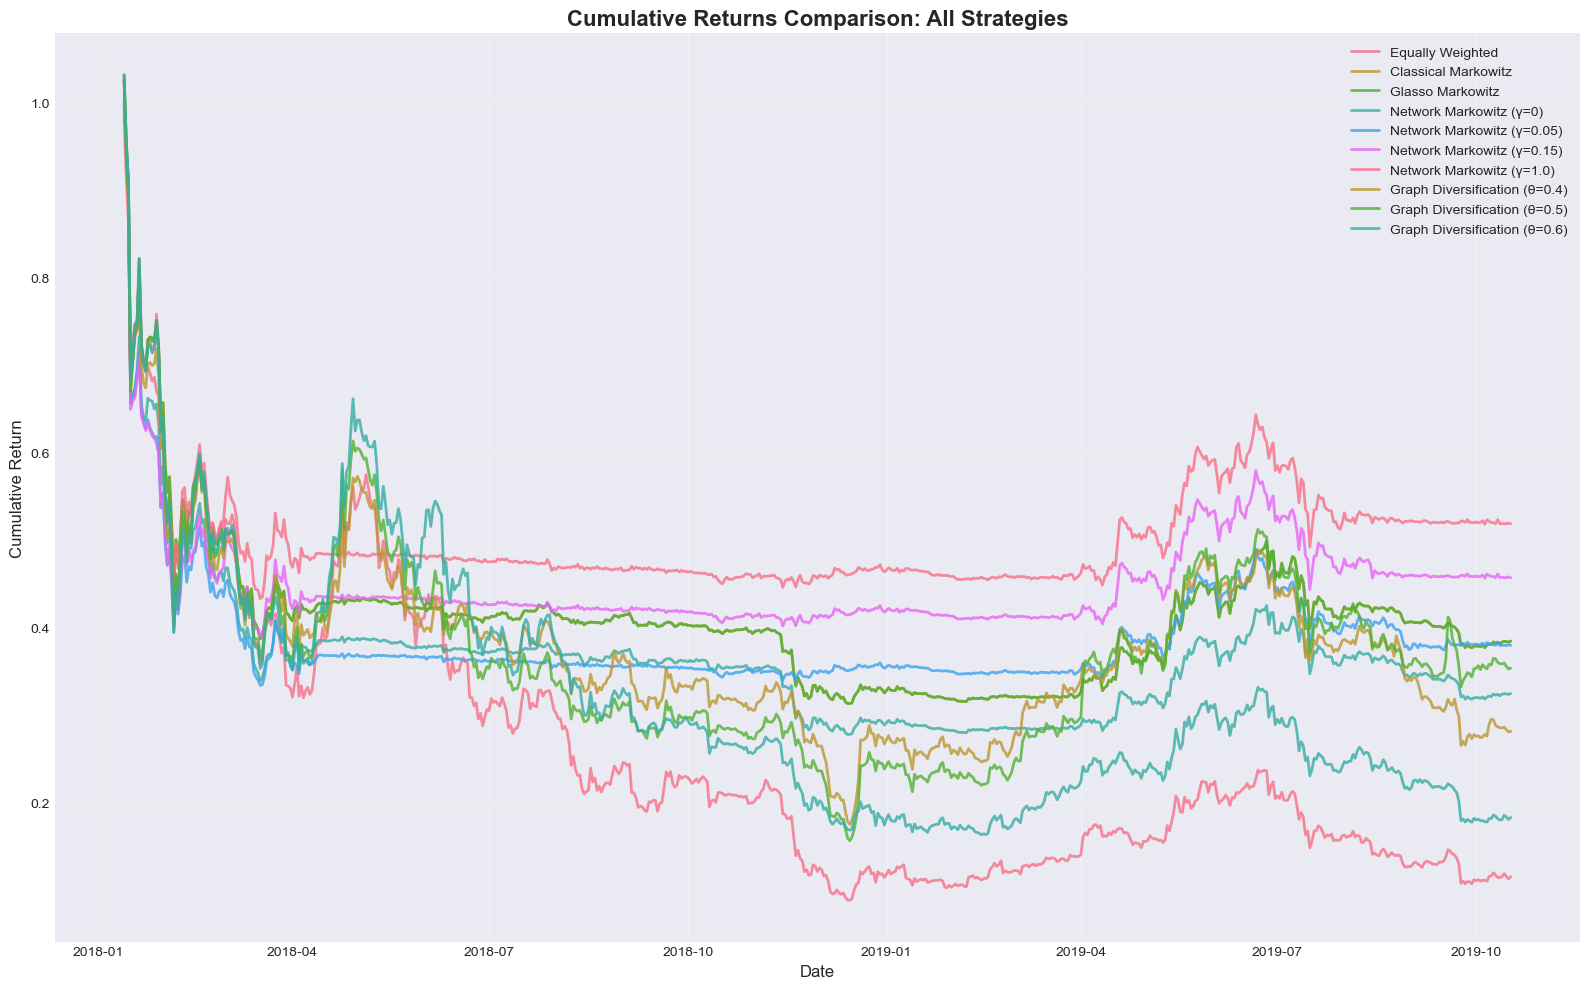

✅ Cumulative returns plot generated


In [18]:
plt.figure(figsize=(16, 10))

# Plot all strategies
for strategy_name, result in results.items():
    plt.plot(result['dates'], result['cumulative_returns'], 
             label=strategy_name, linewidth=2, alpha=0.8)

plt.title('Cumulative Returns Comparison: All Strategies', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Cumulative returns plot generated")

## 8. Comparison: Graph Diversification vs Network Markowitz

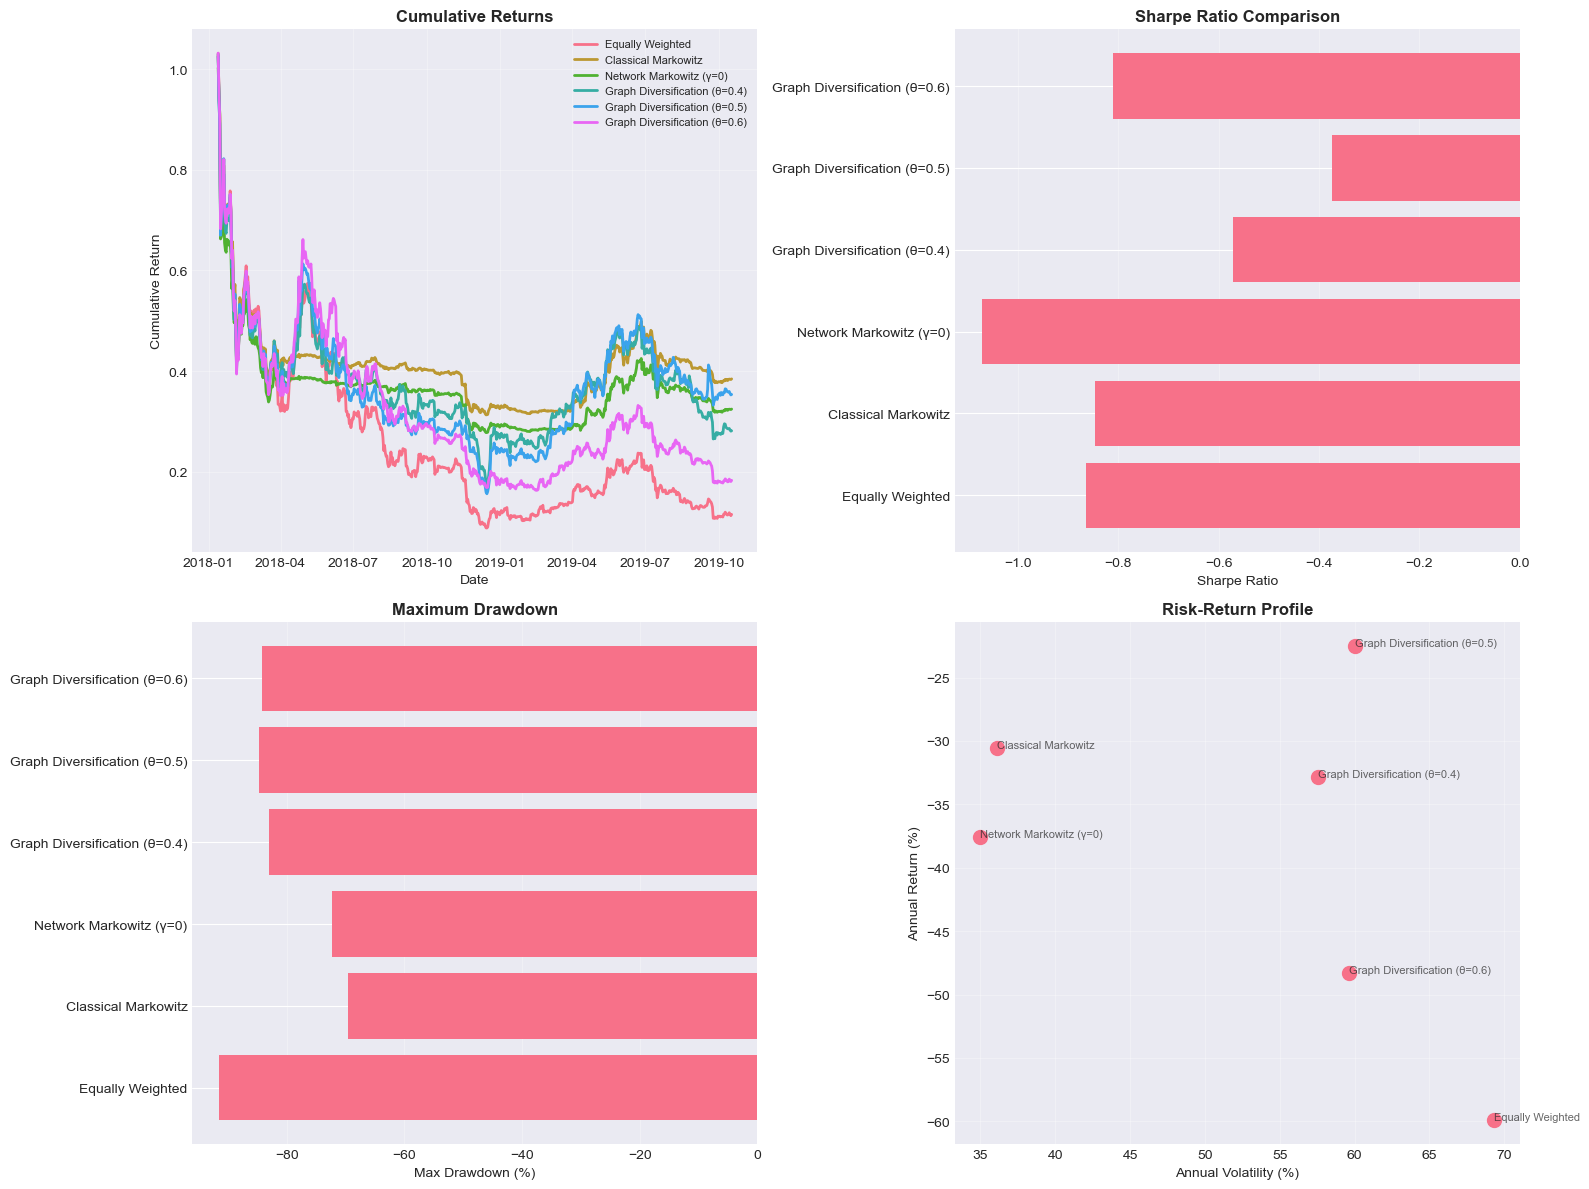

✅ Comparison plots generated


In [19]:
# Focus comparison on new strategy
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Select key strategies for comparison
key_strategies = [
    "Equally Weighted",
    "Classical Markowitz",
    "Network Markowitz (γ=0)",
    "Graph Diversification (θ=0.4)",
    "Graph Diversification (θ=0.5)",
    "Graph Diversification (θ=0.6)"
]

# Plot 1: Cumulative Returns
for name in key_strategies:
    if name in results:
        axes[0, 0].plot(results[name]['dates'], results[name]['cumulative_returns'], 
                       label=name, linewidth=2)
axes[0, 0].set_title('Cumulative Returns', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Cumulative Return')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Sharpe Ratio
sharpe_data = metrics_df[metrics_df['Strategy'].isin(key_strategies)]
axes[0, 1].barh(sharpe_data['Strategy'], sharpe_data['Sharpe Ratio'])
axes[0, 1].set_title('Sharpe Ratio Comparison', fontweight='bold')
axes[0, 1].set_xlabel('Sharpe Ratio')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot 3: Max Drawdown
axes[1, 0].barh(sharpe_data['Strategy'], sharpe_data['Max Drawdown (%)'])
axes[1, 0].set_title('Maximum Drawdown', fontweight='bold')
axes[1, 0].set_xlabel('Max Drawdown (%)')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: Return vs Risk
axes[1, 1].scatter(sharpe_data['Annual Volatility (%)'], sharpe_data['Annual Return (%)'], s=100)
for idx, row in sharpe_data.iterrows():
    axes[1, 1].annotate(row['Strategy'], 
                       (row['Annual Volatility (%)'], row['Annual Return (%)']),
                       fontsize=8, alpha=0.7)
axes[1, 1].set_title('Risk-Return Profile', fontweight='bold')
axes[1, 1].set_xlabel('Annual Volatility (%)')
axes[1, 1].set_ylabel('Annual Return (%)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Comparison plots generated")

## 9. Export Results

In [20]:
# Save metrics to CSV
metrics_df.to_csv('strategy_comparison_with_diversify_results.csv', index=False)
print("✅ Results exported to 'strategy_comparison_with_diversify_results.csv'")

# Display final summary
print("\n" + "="*100)
print("FINAL SUMMARY - TOP 3 STRATEGIES BY SHARPE RATIO")
print("="*100)
top3 = metrics_df.nlargest(3, 'Sharpe Ratio')[['Strategy', 'Sharpe Ratio', 'Annual Return (%)', 'Max Drawdown (%)']]
print(top3.to_string(index=False))
print("="*100)

✅ Results exported to 'strategy_comparison_with_diversify_results.csv'

FINAL SUMMARY - TOP 3 STRATEGIES BY SHARPE RATIO
                     Strategy  Sharpe Ratio  Annual Return (%)  Max Drawdown (%)
Graph Diversification (θ=0.5)     -0.374686         -22.483812        -84.759091
Graph Diversification (θ=0.4)     -0.571108         -32.853640        -83.007150
    Network Markowitz (γ=1.0)     -0.612715         -20.146870        -55.968303
